# Imports Explanation
Imports PyTorch for LSTM (long short-term memory) model, Yfinance for stock data, Scikit-Learn for scaling, Numpy for arrays, Matplotlib for plots.

In [1]:
import torch  # Torch provides tensors and device management (CPU/GPU).
import torch.nn as nn  # nn module for building neural networks like LSTM.
from torch.utils.data import Dataset, DataLoader  # Dataset and DataLoader for custom time series data handling and batching.
import yfinance as yf  # Yfinance downloads historical stock data from Yahoo Finance.
import pandas as pd  # Pandas handles time series data as DataFrames for easy manipulation.
from sklearn.preprocessing import MinMaxScaler  # MinMaxScaler normalizes data to 0-1 range for stable LSTM training.
import numpy as np  # Numpy for array operations and reshaping data.
import matplotlib.pyplot as plt  # Matplotlib for plotting actual vs predicted prices.

# Data Loading Explanation
Downloads historical AAPL (Apple) stock close prices from Yfinance and scales them to 0-1 for model stability.

In [2]:
data = yf.download('AAPL', start='2020-01-01', end='2025-07-25')  # Downloads AAPL stock data from Yahoo Finance; start/end define date range.
close_prices = data['Close'].values.reshape(-1, 1)  # Extracts 'Close' column as numpy array and reshapes to 2D for scaler compatibility.
scaler = MinMaxScaler(feature_range=(0, 1))  # Initializes scaler to normalize data between 0 and 1.
scaled_prices = scaler.fit_transform(close_prices)  # Fits the scaler to data and transforms (normalizes) the prices.
print(scaled_prices[:5])  # Prints first 5 scaled values to inspect normalization.

C:\Users\rober\AppData\Local\Temp\ipykernel_6116\1731221874.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2020-01-01', end='2025-07-25')  # Downloads AAPL stock data from Yahoo Finance; start/end define date range.
[*********************100%***********************]  1 of 1 completed

[[0.08941492]
 [0.08595432]
 [0.08876293]
 [0.08709201]
 [0.09278064]]


# Sequence Preparation Explanation
Creates input sequences (60 days) and targets for LSTM; reshapes for model input.

In [3]:
def create_sequences(data, seq_length=60):  # Function to generate time series sequences; seq_length is look-back window.
    X, y = [], []  # Initializes empty lists for inputs (X) and targets (y).
    for i in range(len(data) - seq_length):  # Loops through data, stopping seq_length before end to have targets.
        X.append(data[i:i+seq_length])  # Appends sequence of seq_length values as input.
        y.append(data[i+seq_length])  # Appends next value as target.
    return np.array(X), np.array(y)  # Converts lists to numpy arrays for tensor conversion.
X, y = create_sequences(scaled_prices)  # Calls function to create sequences from scaled data.
X = torch.tensor(X, dtype=torch.float32)  # Converts X to PyTorch tensor with float32 type for model compatibility.
y = torch.tensor(y, dtype=torch.float32)  # Converts y to PyTorch tensor with float32 type.
print(X.shape, y.shape)  # Prints shapes (e.g., X: (samples, 60, 1), y: (samples, 1)) to verify dimensions.

torch.Size([1337, 60, 1]) torch.Size([1337, 1])


# Model Building Explanation
Defines LSTM model with hidden size 50 and linear output for prediction.

In [4]:
class StockLSTM(nn.Module):  # Renamed class to StockLSTM to avoid conflicting with nn.LSTM.
    def __init__(self):  # Initializes model layers.
        super(StockLSTM, self).__init__()  # Calls parent constructor (use this or super().__init__()—both work, but keep consistent).
        self.lstm = nn.LSTM(1, 50, batch_first=True)  # LSTM layer: input size 1 (close price), hidden size 50, batch_first for (batch, seq, feature) input.
        self.fc = nn.Linear(50, 1)  # Linear layer: maps hidden state to single output (predicted price).
    def forward(self, x):  # Forward pass.
        _, (h, _) = self.lstm(x)  # Runs LSTM; returns hidden state h (ignore cell state).
        return self.fc(h.squeeze(0))  # Passes last hidden state through linear layer; squeeze removes extra dimension.

model = StockLSTM()  # Instantiates the renamed model.
criterion = nn.MSELoss()  # Mean Squared Error loss for regression.
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer with learning rate 0.001 for weight updates.

# Training Explanation
Trains the LSTM on sequenced data over 50 epochs, using MSE loss and Adam optimizer. Loss should decrease as the model learns temporal patterns in stock prices.

In [5]:
epochs = 100  # Number of training epochs (full passes through the data); 10 is a starting point—adjust for convergence.
for epoch in range(epochs):  # Loop over each epoch to train iteratively.
    optimizer.zero_grad()  # Resets gradients to zero before each forward pass to prevent accumulation from previous iterations.
    outputs = model(X)  # Forward pass: feeds input sequences through the model to get predictions.
    loss = criterion(outputs, y)  # Computes Mean Squared Error loss between model predictions and actual targets.
    loss.backward()  # Backpropagates the loss to calculate gradients for each model parameter.
    optimizer.step()  # Updates the model weights using the computed gradients and Adam optimizer rules.
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")  # Prints the current epoch and loss value to monitor training progress (loss should decrease over time).

Epoch 1, Loss: 0.2153
Epoch 2, Loss: 0.2019
Epoch 3, Loss: 0.1890
Epoch 4, Loss: 0.1767
Epoch 5, Loss: 0.1648
Epoch 6, Loss: 0.1532
Epoch 7, Loss: 0.1420
Epoch 8, Loss: 0.1311
Epoch 9, Loss: 0.1204
Epoch 10, Loss: 0.1100
Epoch 11, Loss: 0.0997
Epoch 12, Loss: 0.0897
Epoch 13, Loss: 0.0800
Epoch 14, Loss: 0.0704
Epoch 15, Loss: 0.0613
Epoch 16, Loss: 0.0526
Epoch 17, Loss: 0.0445
Epoch 18, Loss: 0.0373
Epoch 19, Loss: 0.0313
Epoch 20, Loss: 0.0269
Epoch 21, Loss: 0.0246
Epoch 22, Loss: 0.0249
Epoch 23, Loss: 0.0277
Epoch 24, Loss: 0.0316
Epoch 25, Loss: 0.0346
Epoch 26, Loss: 0.0353
Epoch 27, Loss: 0.0338
Epoch 28, Loss: 0.0311
Epoch 29, Loss: 0.0282
Epoch 30, Loss: 0.0258
Epoch 31, Loss: 0.0241
Epoch 32, Loss: 0.0231
Epoch 33, Loss: 0.0226
Epoch 34, Loss: 0.0226
Epoch 35, Loss: 0.0228
Epoch 36, Loss: 0.0231
Epoch 37, Loss: 0.0233
Epoch 38, Loss: 0.0234
Epoch 39, Loss: 0.0235
Epoch 40, Loss: 0.0233
Epoch 41, Loss: 0.0230
Epoch 42, Loss: 0.0226
Epoch 43, Loss: 0.0221
Epoch 44, Loss: 0.02

# Forecasting and Plotting Explanation
Sets model to eval mode, generates predictions, inverse-scales to original prices, and plots actual vs predicted for visual validation. This step evaluates the trained model by generating forecasts on the data, inverse-scaling back to original prices, and plotting actual vs predicted to visualize performance. Plotting helps assess fit (lines should align closely) and identify issues like lag in predictions.

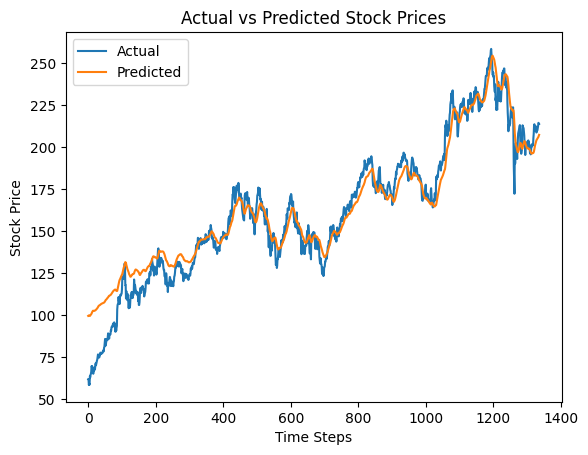

In [6]:
model.eval()  # Sets the model to evaluation mode, disabling training behaviors like dropout (though not used here).
with torch.no_grad():  # Disables gradient computation to save memory and speed up inference since no training is needed.
    predicted = model(X).detach().numpy()  # Runs forward pass on inputs to get predictions; detach removes from graph, numpy converts for scaling/plotting.
predicted = scaler.inverse_transform(predicted)  # Inverse-transforms predictions back to original price scale using the fitted scaler.
actual = scaler.inverse_transform(y.numpy())  # Inverse-transforms actual targets for direct comparison.
plt.plot(actual, label='Actual')  # Plots the actual prices as a line with label for legend.
plt.plot(predicted, label='Predicted')  # Plots the predicted prices as a line with label.
plt.legend()  # Adds a legend to distinguish actual and predicted lines.
plt.title('Actual vs Predicted Stock Prices')  # Sets the plot title for clarity.
plt.xlabel('Time Steps')  # Labels the x-axis as time steps (days).
plt.ylabel('Stock Price')  # Labels the y-axis as stock price.
plt.show()  # Displays the plot in the notebook output.

# Debug Explanation
This step computes MAE (mean absolute error) to quantify forecast error in dollars and adds an optional train/test split to check overfitting (train on 80%, test on 20%). MAE provides an interpretable metric (e.g., average $5 error), and splitting helps detect if the model memorizes training data.

In [7]:
from sklearn.metrics import mean_absolute_error  # Imports MAE metric from Scikit-Learn to measure average absolute difference between actual and predicted.
mae = mean_absolute_error(actual, predicted)  # Calculates MAE using actual and predicted values (e.g., ~5-10 for stock prices).
print(f"MAE: {mae:.2f}")  # Prints MAE formatted to 2 decimals for readability.

# Optional: Train/Test Split for Overfitting Check
split = int(len(scaled_prices) * 0.8)  # Calculates index for 80% train/20% test split based on data length.
train_data = scaled_prices[:split]  # Slices the first 80% of scaled data for training.
test_data = scaled_prices[split:]  # Slices the remaining 20% for testing.
X_train, y_train = create_sequences(train_data)  # Creates sequences and targets for training data using the function from Step 5.
X_test, y_test = create_sequences(test_data)  # Creates sequences and targets for testing data.
X_train = torch.tensor(X_train, dtype=torch.float32)  # Converts train inputs to PyTorch tensor with float32 type.
y_train = torch.tensor(y_train, dtype=torch.float32)  # Converts train targets to tensor.
X_test = torch.tensor(X_test, dtype=torch.float32)  # Converts test inputs to tensor.
y_test = torch.tensor(y_test, dtype=torch.float32)  # Converts test targets to tensor.
# To use: Retrain model on X_train/y_train (rerun Step 7 with X_train/y_train), predict on X_test, compute MAE on test predictions vs y_test.

MAE: 7.62
